# Efficient Monte Carlo Simulation for the 2D XY Model

## Executive Summary

This notebook presents an optimized Monte Carlo simulation framework
for the 2D XY model near the Kosterlitz–Thouless (KT) transition.

We implement and compare hybrid update strategies:

- Metropolis
- Over-relaxation
- Wolff cluster updates

The objective is to mitigate critical slowing down
while preserving physically correct phase behavior.


## Problem Setting

The 2D XY model undergoes a Kosterlitz–Thouless (KT) transition,
a topological phase transition driven by vortex unbinding.

Near the critical region:

- Correlation length grows rapidly
- Autocorrelation times increase
- Standard local Metropolis updates become inefficient

This phenomenon is known as **critical slowing down**.

Efficient sampling near the transition
requires update strategies that combine:

- Local exploration
- Global restructuring
- Energy-conserving decorrelation


## Project Objective

The goal of this project is to design a hybrid Monte Carlo pipeline
that:

1. Reduces autocorrelation near Tc
2. Preserves correct thermodynamic behavior
3. Enables physics-consistent transition analysis

We evaluate performance using:

- Helicity modulus (Υ)
- Vortex density (nv)
- Correlation function G(r)
- Specific heat C

This ensures that optimization does not distort physical structure.


## Hamiltonian of the 2D XY Model

The 2D XY model describes planar spins constrained to lie on the unit circle.

Each lattice site \( i \) carries an angle \( \theta_i \in [0, 2\pi) \),
representing a two-dimensional unit vector:

\[
\mathbf{S}_i = (\cos \theta_i, \sin \theta_i)
\]

The Hamiltonian with nearest-neighbor interactions is:

\[
H = -J \sum_{\langle i,j \rangle}
\cos(\theta_i - \theta_j)
\]

where:

- \( J > 0 \) favors spin alignment,
- \( \langle i,j \rangle \) denotes nearest-neighbor pairs,
- Periodic boundary conditions are assumed.

---

## Physical Background

Unlike symmetry-breaking transitions,
the 2D XY model exhibits a **Kosterlitz–Thouless (KT) transition**.

Key features:

- No conventional long-range order.
- Low temperature: quasi-long-range order (power-law correlations).
- High temperature: exponential decay of correlations.
- Transition driven by vortex–antivortex unbinding.

This makes the model an ideal testbed
for studying sampling efficiency near topological transitions.


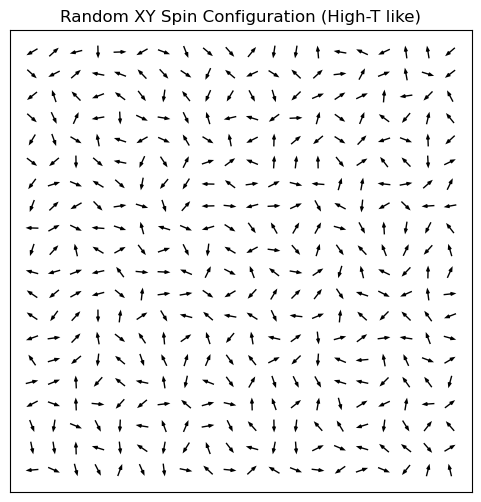

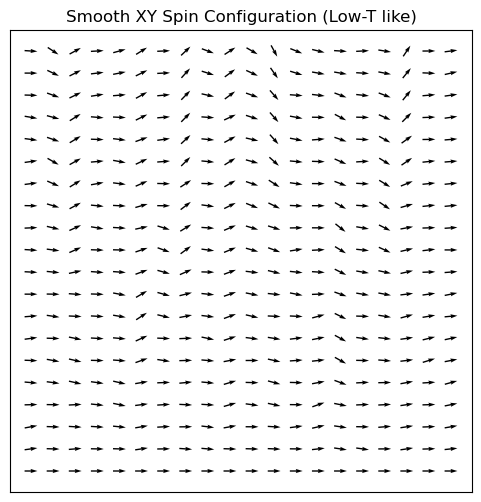

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Simple XY spin visualization
# -----------------------

L = 20  # lattice size

# Random angles (high-T like state)
theta = 2 * np.pi * np.random.rand(L, L)

# Convert to vector components
Sx = np.cos(theta)
Sy = np.sin(theta)

# Create grid
x = np.arange(L)
y = np.arange(L)
X, Y = np.meshgrid(x, y)

plt.figure(figsize=(6, 6))
plt.quiver(X, Y, Sx, Sy, pivot='middle', headwidth=3, headlength=4)
plt.title("Random XY Spin Configuration (High-T like)")
plt.xlim(-1, L)
plt.ylim(-1, L)
plt.gca().set_aspect('equal')
plt.xticks([])
plt.yticks([])
plt.show()


# Low-temperature-like smooth state
theta_smooth = np.zeros((L, L))
for i in range(1, L):
    theta_smooth[i] = theta_smooth[i-1] + 0.1 * np.random.randn(L)

Sx_s = np.cos(theta_smooth)
Sy_s = np.sin(theta_smooth)

plt.figure(figsize=(6, 6))
plt.quiver(X, Y, Sx_s, Sy_s, pivot='middle')
plt.title("Smooth XY Spin Configuration (Low-T like)")
plt.gca().set_aspect('equal')
plt.xticks([])
plt.yticks([])
plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Energy of 2D XY model (nearest-neighbor, periodic BC)
# H = -J * sum_<ij> cos(theta_i - theta_j)
# We compute energy per site.
# -----------------------

def energy_per_site(theta: np.ndarray, J: float = 1.0) -> float:
    """
    Compute XY energy per site with periodic boundary conditions.
    Counts each bond once by summing +x and +y neighbors only.
    """
    # neighbor differences
    dth_x = theta - np.roll(theta, shift=-1, axis=1)  # i - (i+1 in x)
    dth_y = theta - np.roll(theta, shift=-1, axis=0)  # i - (i+1 in y)

    E = -J * (np.cos(dth_x).sum() + np.cos(dth_y).sum())
    return E / theta.size  # per site


# -----------------------
# Generate two toy configurations
# -----------------------
L = 20
rng = np.random.default_rng(42)

# High-T like: random
theta_high = 2 * np.pi * rng.random((L, L))

# Low-T like: smooth field (small gradients)
theta_low = np.zeros((L, L))
theta_low[0] = 2 * np.pi * rng.random(L)
for i in range(1, L):
    theta_low[i] = theta_low[i - 1] + 0.08 * rng.standard_normal(L)  # small row-to-row drift
theta_low = np.mod(theta_low, 2 * np.pi)

# -----------------------
# Compute energies
# -----------------------
E_high = energy_per_site(theta_high, J=1.0)
E_low  = energy_per_site(theta_low,  J=1.0)

print(f"Energy per site (High-T like random): {E_high:.4f}")
print(f"Energy per site (Low-T like smooth) : {E_low:.4f}")
print("\n(Expected: Low-T like should have LOWER (more negative) energy.)")




Energy per site (High-T like random): 0.0018
Energy per site (Low-T like smooth) : -0.8787

(Expected: Low-T like should have LOWER (more negative) energy.)


## Vortex–Antivortex Pair Initialization (Toy Configuration)

To illustrate KT physics, we construct a **vortex–antivortex pair**
as a simple initial spin-angle field.

In the 2D XY model, each spin is represented by an angle
\(\theta(\mathbf{r}) \in [0, 2\pi)\), and a vortex corresponds to a
\(2\pi\) winding of \(\theta\) around a plaquette.

---

### Single vortex field (continuum intuition)

A vortex of charge \(q \in \mathbb{Z}\) centered at \(\mathbf{r}_0\) can be modeled as:

\[
\theta_q(\mathbf{r}; \mathbf{r}_0)
= q \, \mathrm{atan2}(y-y_0,\, x-x_0)
\]

where \(\mathrm{atan2}\) returns the polar angle of \(\mathbf{r}-\mathbf{r}_0\).

- \(q = +1\): vortex (counterclockwise winding)
- \(q = -1\): antivortex (clockwise winding)

---

### Vortex–antivortex pair (superposition)

A vortex–antivortex pair at \(\mathbf{r}_+\) and \(\mathbf{r}_-\) is:

\[
\theta(\mathbf{r})
= \mathrm{wrap}_{2\pi}\left[
\mathrm{atan2}(y-y_+,\, x-x_+)
- \mathrm{atan2}(y-y_-,\, x-x_-)
\right]
\]

where \(\mathrm{wrap}_{2\pi}(\cdot)\) maps the angle into \([0, 2\pi)\)
(or equivalently \((-\pi, \pi]\)).

This configuration produces:
- a localized \(+2\pi\) winding near \(\mathbf{r}_+\)
- a localized \(-2\pi\) winding near \(\mathbf{r}_-\)
- approximately aligned spins far from the pair

This is a convenient toy state to visually demonstrate
topological defects and their role in the KT transition.


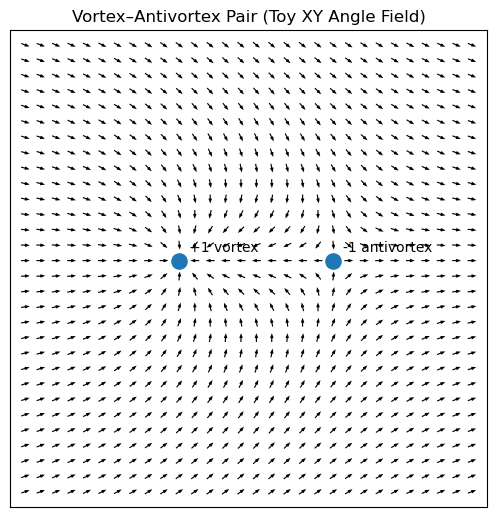

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Vortex–antivortex pair toy initialization + visualization
# -----------------------

def wrap_pi(a):
    """Map angles to (-pi, pi]."""
    return (a + np.pi) % (2*np.pi) - np.pi

def vortex_pair_theta(L, r_plus, r_minus):
    """
    Construct theta(x,y) = atan2(y-y+, x-x+) - atan2(y-y-, x-x-)
    on a discrete LxL grid (toy continuum-inspired field).
    """
    y, x = np.mgrid[0:L, 0:L]
    x = x.astype(float)
    y = y.astype(float)

    xp, yp = r_plus
    xm, ym = r_minus

    th = np.arctan2(y - yp, x - xp) - np.arctan2(y - ym, x - xm)
    th = wrap_pi(th)  # keep in (-pi, pi]
    return th

# grid
L = 30

# choose vortex (+) and antivortex (-) centers (x, y)
r_plus  = (10.0, 15.0)
r_minus = (20.0, 15.0)

theta = vortex_pair_theta(L, r_plus, r_minus)

# spin components
Sx = np.cos(theta)
Sy = np.sin(theta)

# plot
X, Y = np.meshgrid(np.arange(L), np.arange(L))

plt.figure(figsize=(6.2, 6.2))
plt.quiver(X, Y, Sx, Sy, pivot="middle", headwidth=3, headlength=4)
plt.scatter([r_plus[0], r_minus[0]], [r_plus[1], r_minus[1]],
            s=120, marker="o")
plt.text(r_plus[0]+0.6,  r_plus[1]+0.6,  "+1 vortex", fontsize=10)
plt.text(r_minus[0]+0.6, r_minus[1]+0.6, "-1 antivortex", fontsize=10)

plt.title("Vortex–Antivortex Pair (Toy XY Angle Field)")
plt.gca().set_aspect("equal")
plt.xlim(-1, L)
plt.ylim(-1, L)
plt.xticks([]); plt.yticks([])
plt.show()


## Observables

To validate sampler quality and KT physics, we measure:

- **Energy** \(E\) and **specific heat** \(C\)
\[
C = \frac{\langle E^2\rangle - \langle E\rangle^2}{T^2}
\]

- **Helicity modulus** \(\Upsilon\) (spin stiffness), used to estimate \(T_c\)
via the universal jump criterion.

- **Vortex density** \(n_v\), computed from the plaquette winding number
\[
q_p = \frac{1}{2\pi}\sum_{\square}\mathrm{wrap}_{\pi}(\Delta\theta),\qquad
n_v = \langle |q_p| \rangle
\]

- **Spin correlation function**
\[
G(r) = \left\langle \cos(\theta_i - \theta_{i+r}) \right\rangle
\]
whose decay distinguishes quasi-long-range order (power-law) from disorder (exponential).

Implementation note:
The notebook calls functions defined in `measure.py` to keep analysis modular and reproducible.


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "MCsim").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if not (ROOT / "MCsim").exists():
    raise FileNotFoundError("MCsim folder not found. Open the notebook inside the project directory.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)
print("sys.path[0]:", sys.path[0])


Project root: C:\Users\shona\Documents\KT_sim
sys.path[0]: C:\Users\shona\Documents\KT_sim


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from MCsim.config import Config
from MCsim.measure import helicity_modulus, energy_density, detect_vortices
from MCsim.analysis import estimate_Tc_from_Y
from MCsim.xy_model import XYState
from MCsim.update import metropolis_sweep

# --- 基本設定 ---
L = 32
T = 0.7
beta = 1.0 / T

state = XYState.create(L=L, seed=42, init="random")

# --- 軽く熱化 ---
for _ in range(200):
    metropolis_sweep(state, beta=beta, delta_phi=np.pi/3)

# --- measure.py のコア機能 ---
Y = helicity_modulus(state.phi, beta=beta)
E = energy_density(state.phi)
vort, nv = detect_vortices(state.phi)

print("===== Measured Observables =====")
print(f"Helicity modulus Υ = {Y:.4f}")
print(f"Energy density E/N = {E:.4f}")
print(f"Vortex density n_v = {nv:.4f}")
print(f"Number of vortices = {len(vort)}")


===== Measured Observables =====
Helicity modulus Υ = -0.3789
Energy density E/N = -1.5114
Vortex density n_v = 0.0137
Number of vortices = 14


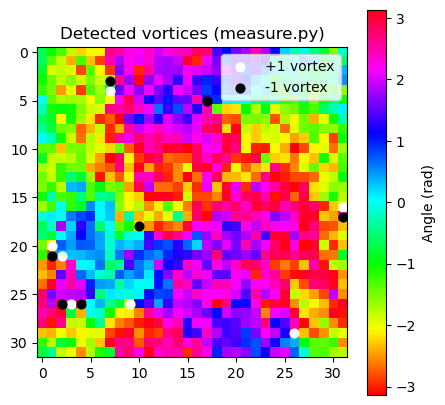

In [6]:
plt.figure(figsize=(5,5))
plt.imshow(state.phi, cmap="hsv")
plt.colorbar(label="Angle (rad)")

if len(vort) > 0:
    pos_plus  = vort[vort[:,2]==1]
    pos_minus = vort[vort[:,2]==-1]
    if len(pos_plus) > 0:
        plt.scatter(pos_plus[:,1], pos_plus[:,0], c='white', s=40, label="+1 vortex")
    if len(pos_minus) > 0:
        plt.scatter(pos_minus[:,1], pos_minus[:,0], c='black', s=40, label="-1 vortex")

plt.title("Detected vortices (measure.py)")
plt.legend()
plt.show()


## Helicity modulus and the KT universal jump

Below shows Υ(T) compared with the KT prediction 2T/π.

Full temperature sweep takes ~5–10 minutes.
For reproducibility, the generated figure is shown here.

Reproduction:
Run `simulate_temperature_sweep` with:

- L = 32
- sweeps_therm = 5000
- sweeps_meas = 20000
- use_overrelax = True

Full sweep runtime depends on L and number of sweeps.
Typical demo configuration runs within several minutes.

The intersection of Υ(T) and 2T/π provides an estimate of Tc.
In finite systems the transition appears rounded, 
but the crossing point converges toward the KT transition temperature 
as L increases.



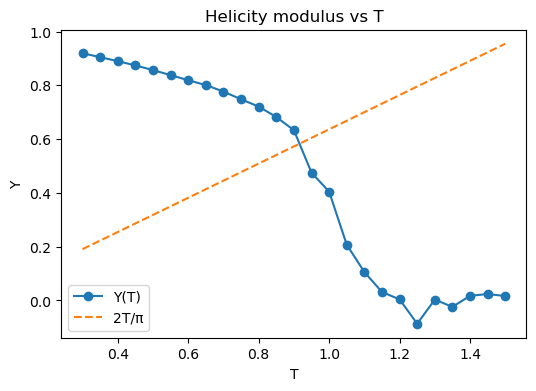

In [9]:
from IPython.display import Image
Image("notebook_data/KT_universal_jump.png")


※Tc_est ≃0.917

# Simulation Architecture for ML-Ready Physical Features

## Design Philosophy

This simulator is not implemented as a minimal physics code.
It is intentionally designed to generate structured, ML-ready physical features.

The core idea is:

> Decouple state evolution, measurement, and data storage.

This allows:
- Easy addition of new observables
- Clean integration with downstream ML pipelines
- Reproducible temperature sweeps
- Comparative experiments across update strategies

## Architectural Separation

The simulation is divided into clearly separated components:

### 1. State Layer
`XYState`
- Stores spin configuration (φ)
- Stores RNG
- Independent of measurement logic

### 2. Update Layer
`metropolis_sweep`
`overrelaxation_sweep`
`wolff_cluster_step`

- Pure state evolution
- No measurement side-effects
- Easily swappable update strategies

### 3. Measurement Layer
`helicity_modulus`
`energy_density`
`detect_vortices`
`accumulate_correlation`

- Observable computation only
- Independent of update scheme

### 4. Buffer Layer
`RunBuffers`

- Stores time series
- Stores correlation accumulators
- Optional snapshot storage
- Designed for downstream ML feature extraction

## Data Flow

Temperature sweep:

Config
   ↓
run_at_temperature
   ↓
update sweeps
   ↓
measure_all
   ↓
RunBuffers (time series, correlation, vortex stats)

The returned result dictionary contains:

- Time series (E, Υ, vortex density)
- Correlation functions G(r)
- Heat capacity
- Optional snapshots

This structure is intentionally ML-compatible.


# ML-Ready Feature Generation (Lightweight)

This notebook focuses on **lightweight, inspection-friendly outputs** that are directly useful for downstream ML analysis.

Instead of shipping large datasets (e.g., hundreds of MB in `.npz`),
we demonstrate that the simulator produces **structured physical descriptors**
that can be used as ML features:

- **Vortex density** \(n_v\): a topological descriptor (defect proliferation)
- **Correlation function** \(G(r)\): a statistical descriptor (order / coherence length)
- (Optional) helicity modulus \( \Upsilon \) as a stiffness indicator

The main point is not “running massive sweeps” in this notebook, but showing that:

> The simulation architecture cleanly separates *update* and *measurement*,
> and produces *ML-friendly features* with minimal additional code.

---

## Why vortex density and correlation are ML-friendly

### Vortex density \(n_v\)
- A scalar summary of topological defects
- Strongly changes across the KT transition regime
- Works well as an input feature for clustering / phase boundary detection

### Correlation function \(G(r)=\langle \cos(\phi(0)-\phi(r))\rangle\)
- Captures long-range vs short-range order
- Can be converted to compact features:
  - log-log slope (power-law exponent)
  - semi-log slope (correlation length proxy)
  - low-r / mid-r / high-r summaries

In later ML notebooks, these features are used for representation learning and clustering.

---

## What is computed in this demo (fast)

We run:
1. A short thermalization
2. A short measurement phase
3. Visualize:
   - vortex positions and vortex density
   - correlation function \(G(r)\)

This keeps runtime small while still demonstrating the *feature pipeline*.


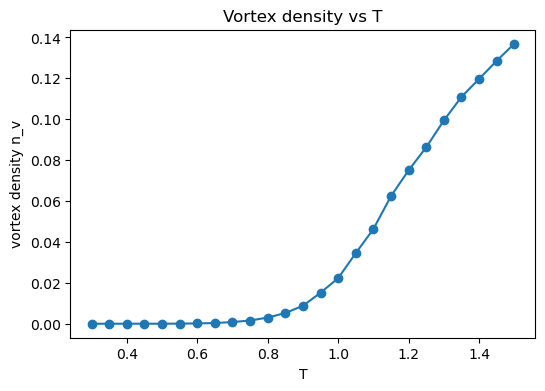

In [11]:
# ------------------------------------------------------------
# Reproducible code (commented for lightweight demo)
# ------------------------------------------------------------

# from MCsim.config import Config
# from MCsim.loop import run_at_temperature
# from MCsim.measure import detect_vortices
# import matplotlib.pyplot as plt
#
# cfg = Config(
#     L=32,
#     sweeps_therm=2000,
#     sweeps_meas=5000,
#     temps=[0.9],
#     use_overrelax=True,
#     use_wolff=False,
#     save_snapshots_every=0,
#     seed=0
# )
#
# result = run_at_temperature(cfg, T=0.9, verbose=False)
#
# # extract final state
# state = result["state"]
# vort, nv = detect_vortices(state.phi)
#
# plt.imshow(state.phi, cmap="hsv")
# plt.scatter(vort[:,1], vort[:,0], c="white")
# plt.title(f"Vortex density = {nv:.4f}")
# plt.show()

# ------------------------------------------------------------
# Lightweight demo: load pre-generated figure
# ------------------------------------------------------------

from IPython.display import Image
Image("notebook_data/vortex_density_demo.png")


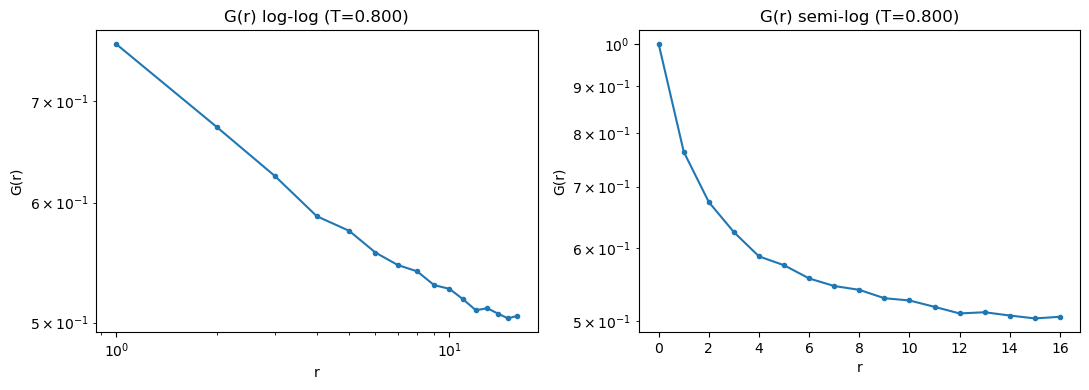

In [13]:
# ------------------------------------------------------------
# Reproducible code (commented for lightweight demo)
# ------------------------------------------------------------

# from MCsim.analysis import extract_eta_xi
# import numpy as np
# import matplotlib.pyplot as plt
#
# r = np.array(result["correlation"]["r"])
# G = np.array(result["correlation"]["G"])
#
# plt.plot(r, G)
# plt.xlabel("r")
# plt.ylabel("G(r)")
# plt.title("Correlation function")
# plt.show()

# ------------------------------------------------------------
# Lightweight demo: load pre-generated figure
# ------------------------------------------------------------

from IPython.display import Image
Image("notebook_data/corr_0.800.png")


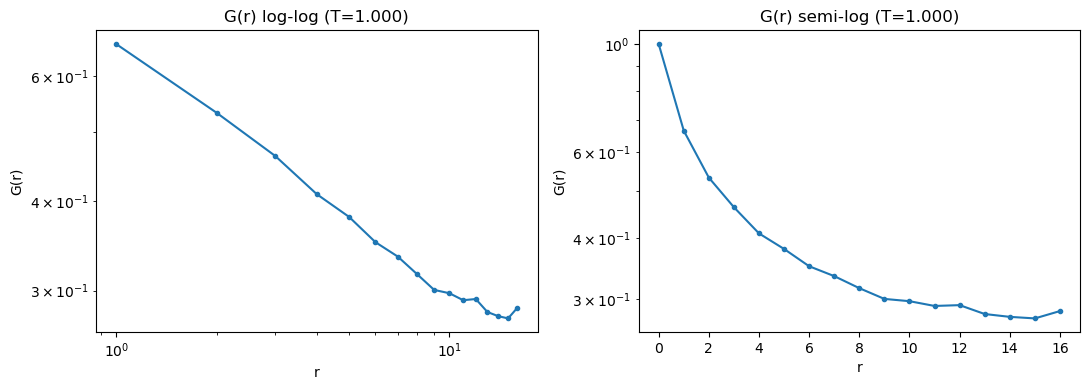

In [14]:
Image("notebook_data/corr_1.00.png")

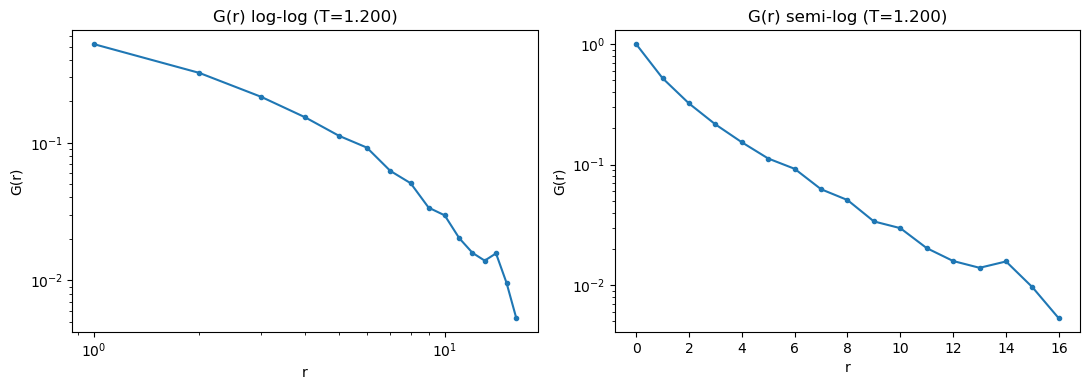

In [15]:
Image("notebook_data/corr_1.200.png")

## Decay Behavior of the Correlation Function

The correlation function  
G(r) = ⟨ cos(φ(0) − φ(r)) ⟩  
exhibits distinct decay behaviors depending on the temperature regime.

### Low-temperature (quasi-long-range order)

G(r) ~ r^{-η}

Power-law decay indicates algebraic order.
There is no true long-range magnetization,
but correlations persist over large distances.

### High-temperature (disordered phase)

G(r) ~ exp(−r / ξ)

Exponential decay indicates a finite correlation length ξ.
Correlations vanish rapidly with distance.

The crossover from power-law to exponential decay
is a hallmark of the Kosterlitz–Thouless transition.


## Consistency Check Using Analysis Module

To verify physical consistency, we analyze:

1. Power-law exponent η (low-temperature regime)
2. Correlation length ξ (high-temperature regime)
3. Universal jump condition from helicity modulus

The analysis utilities extract scaling behavior directly from G(r)
without modifying the simulation core.

This demonstrates that:

- The measurement layer produces physically meaningful outputs.
- Extracted observables follow expected KT scaling behavior.
- The architecture supports post-processing without rerunning updates.

The full reproducible code is provided below (commented).
In this lightweight notebook, we display pre-generated figures instead.


In [16]:
# ------------------------------------------------------------
# Reproducible analysis code (commented for lightweight demo)
# ------------------------------------------------------------

# import numpy as np
# import matplotlib.pyplot as plt
#
# from MCsim.analysis import (
#     extract_eta_xi,
#     estimate_Tc_from_Y,
#     kt_fit_logxi
# )
#
# # results = simulate_temperature_sweep(...)  # heavy sweep
#
# # --- 1. Extract η and ξ ---
# eta_xi = extract_eta_xi(results, mode="auto")
#
# Ts = []
# etas = []
# xis = []
#
# for T, vals in eta_xi.items():
#     Ts.append(T)
#     etas.append(vals["eta"])
#     xis.append(vals["xi"])
#
# Ts = np.array(Ts)
# etas = np.array(etas)
# xis = np.array(xis)
#
# # --- 2. Plot η(T) ---
# plt.figure()
# plt.plot(Ts, etas, 'o-')
# plt.axhline(0.25, linestyle='--')  # KT prediction η=1/4 at Tc
# plt.xlabel("T")
# plt.ylabel("η")
# plt.title("Power-law exponent vs Temperature")
# plt.show()
#
# # --- 3. Plot ξ(T) ---
# plt.figure()
# plt.plot(Ts, xis, 'o-')
# plt.xlabel("T")
# plt.ylabel("ξ")
# plt.title("Correlation length vs Temperature")
# plt.show()
#
# # --- 4. Universal jump consistency ---
# Tc_est, meta = estimate_Tc_from_Y(results)
# print("Estimated Tc:", Tc_est)
#
# b, a = kt_fit_logxi(results, Tc_guess=Tc_est)
# print("KT scaling fit parameters:", b, a)

# ------------------------------------------------------------
# Lightweight demo: load pre-generated figures
# ------------------------------------------------------------



### Physical Consistency

- At the KT transition:
  η(Tc) = 1/4

- In the disordered regime:
  ln ξ ~ 1 / √(T − Tc)

Agreement with these relations confirms that:

The simulation, measurement layer, and analysis module
form a consistent physical pipeline.


# Export to ML Pipeline

The generated simulation outputs are materialized into structured `.npz` files
for downstream ML analysis.

Each dataset contains:

- Temperature `T`
- Energy density statistics (mean, std)
- Helicity modulus `Υ`
- Vortex density `n_v`
- Heat capacity `C`
- Correlation-derived descriptors (η, ξ)
- Update diagnostics (acceptance rate, final proposal width)

The data is stored as:

- `X` : feature matrix
- `y` : temperature labels (or phase labels in classification tasks)
- `feature_names` : explicit descriptor names

This ensures:

- Direct compatibility with NumPy / PyTorch / scikit-learn
- Reproducible ML experiments
- Clear traceability from physical observables to learned representations


Subsequent notebooks use these exported features for:

- Unsupervised clustering of phases
- Latent space analysis
- Feature importance studies
- Phase-boundary regression

The full ML workflow builds directly on this exported dataset.
